In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Real Goal of this project is to learn deployment throuh fastapi

In [ ]:
# data 
df=pd.read_csv('insurance.csv')
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         100 non-null    int64  
 1   weight                      100 non-null    float64
 2   height                      100 non-null    float64
 3   income_lpa                  100 non-null    float64
 4   smoker                      100 non-null    bool   
 5   city                        100 non-null    str    
 6   occupation                  100 non-null    str    
 7   insurance_premium_category  100 non-null    str    
dtypes: bool(1), float64(3), int64(1), str(3)
memory usage: 7.8 KB


array([1.56, 1.83, 1.64, 1.55, 1.6 , 1.66, 1.68, 1.78, 1.58, 1.73, 1.77,
       1.56, 1.78, 1.84, 1.65, 1.68, 1.59, 1.7 , 1.8 , 1.6 , 1.85, 1.84,
       1.83, 1.78, 1.66, 1.55, 1.61, 1.78, 1.79, 1.66, 1.73, 1.83, 1.9 ,
       1.76, 1.75, 1.69, 1.64, 1.79, 1.83, 1.68, 1.53, 1.63, 1.79, 1.71,
       1.6 , 1.5 , 1.57, 1.87, 1.66, 1.58, 1.88, 1.62, 1.57, 1.85, 1.61,
       1.73, 1.55, 1.69, 1.79, 1.82, 1.81, 1.68, 1.83, 1.82, 1.78, 1.68,
       1.59, 1.82, 1.87, 1.75, 1.65, 1.81, 1.81, 1.62, 1.54, 1.74, 1.5 ,
       1.74, 1.85, 1.56, 1.67, 1.61, 1.77, 1.85, 1.73, 1.86, 1.89, 1.6 ,
       1.76, 1.89, 1.6 , 1.76, 1.85, 1.85, 1.78, 1.57, 1.54, 1.8 , 1.82,
       1.59])

([<matplotlib.patches.Wedge at 0x28a3d843890>,
 [Text(-0.28358623166371233, 1.2686917865308247, 'False'),
  Text(0.2399576744876166, -1.0735084137790887, 'True')],
 [Text(-0.174514604100746, 0.7807334070958921, '57.00%'),
  Text(0.13088600426597266, -0.5855500438795028, '43.00%')])

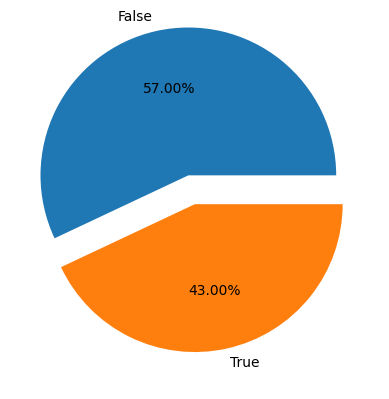

In [26]:
val=df['smoker'].value_counts()
label=df['smoker'].unique()
plt.pie(val,labels=label,explode=[0.2,0],autopct='%1.2f%%')

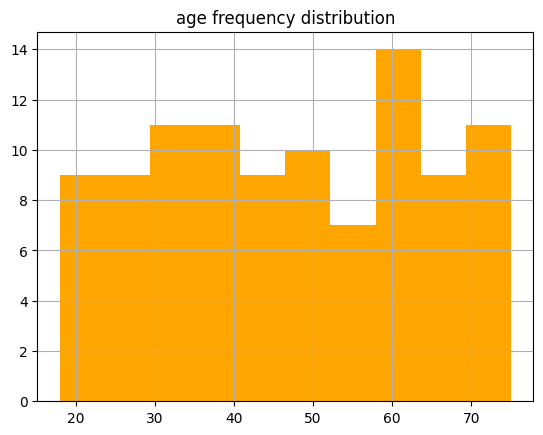

In [30]:
plt.hist(df['age'],color='orange')
plt.grid()
plt.title('age frequency distribution')
plt.show()

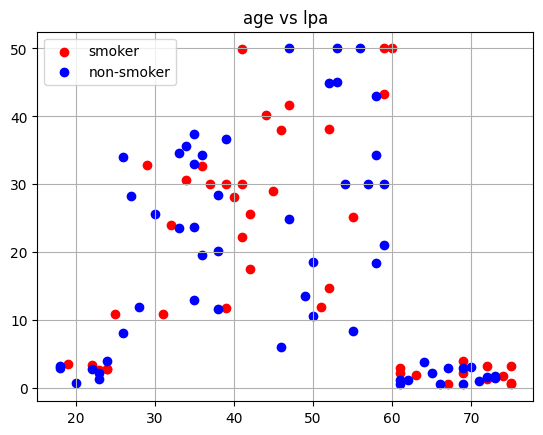

In [42]:
plt.scatter(df[df['smoker']==True]['age'],df[df['smoker']==True]['income_lpa'],c='red',label='smoker')
plt.scatter(df[df['smoker']==False]['age'],df[df['smoker']==False]['income_lpa'],c='blue',label='non-smoker')
plt.title('age vs lpa')
plt.legend(loc='upper left')
plt.grid()
plt.show()

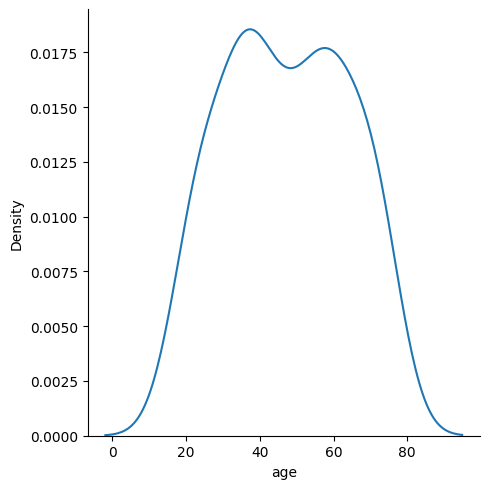

In [49]:
sns.displot(data=df,x=df['age'],kind='kde')

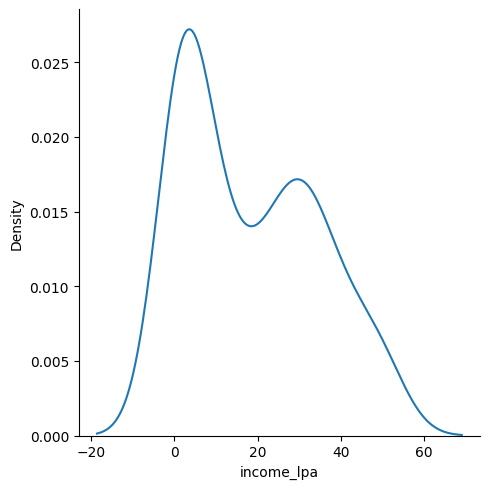

In [50]:
sns.displot(data=df,x='income_lpa',kind='kde')

In [ ]:
# Feature engineering 

# 1.adding bmi column
df['bmi']=df['weight']/df['height']**2


#df.drop(['weight','height'],axis=1,inplace=True)

In [ ]:
# 2 age_group 
def age_group(series):
    if series < 60:
        if series < 45:
            if series <25:
                return 'young'
            else:
                return 'adult'
        else:
            return 'middleage'
    else:
      return 'senior'
df['age_group']=df['age'].apply(age_group)
df['age_group'].value_counts()
#df.drop('age',axis=1,inplace=True)

In [73]:
# 3 lifestyle_risk

def risk(df):
    if df['bmi']>30 and df['smoker']:
        return 'high'
    elif df['bmi']>27 and df['smoker']:
        return 'mid'
    else:
        return 'low'

df['risk']=df.apply(risk,axis=1)


In [ ]:
# tier to cities 
tier1= [
    "Mumbai",
    "Delhi",
    "Bengaluru",
    "Chennai",
    "Kolkata",
    "Hyderabad",
    "Pune",
    "Ahmedabad"
]
tier2= [
    "Agra", "Ajmer", "Akola", "Aligarh", "Amravati", "Amritsar", "Anand",
    "Asansol", "Aurangabad", "Bareilly", "Bardhaman", "Belagavi", "Berhampur",
    "Bhavnagar", "Bhiwandi", "Bhopal", "Bhubaneswar", "Bikaner", "Bilaspur",
    "Bokaro Steel City", "Bellary", "Bhilai", "Chandigarh", "Coimbatore",
    "Cuttack", "Dahod", "Dehradun", "Dhule", "Dombivli", "Dhanbad", "Durgapur",
    "Erode", "Faridabad", "Ghaziabad", "Gorakhpur", "Guntur", "Gurgaon",
    "Guwahati", "Gwalior", "Hamirpur", "Hubballi–Dharwad", "Indore", "Jabalpur",
    "Jaipur", "Jalandhar", "Jalgaon", "Jammu", "Jamshedpur", "Jamnagar",
    "Jhansi", "Jodhpur", "Kalaburagi", "Kakinada", "Kannur", "Kanpur",
    "Karimnagar", "Karnal", "Kochi", "Kolhapur", "Kollam", "Kota", "Kozhikode",
    "Kumbakonam", "Kurnool", "Ludhiana", "Lucknow", "Madurai", "Malappuram",
    "Mathura", "Mangaluru", "Meerut", "Mohali", "Moradabad", "Mysuru", "Nagpur",
    "Nanded", "Nadiad", "Nashik", "Nellore", "Noida", "Patna", "Pimpri-Chinchwad",
    "Puducherry", "Purulia", "Prayagraj", "Raipur", "Rajamahendravaram", "Rajkot",
    "Ranchi", "Rourkela", "Ratlam", "Raichur", "Saharanpur", "Salem", "Sangli",
    "Shimla", "Siliguri", "Solapur", "Srinagar", "Surat", "Thanjavur",
    "Thiruvananthapuram", "Thrissur", "Tiruchirappalli", "Tirunelveli",
    "Tiruvannamalai", "Ujjain", "Vijayapura", "Vadodara", "Varanasi",
    "Vasai-Virar", "Vijayawada", "Visakhapatnam", "Vellore", "Warangal"
]
def tier(df):
    if df['city'] in tier1:
        return 1
    elif df['city'] in tier2:
        return 2
    else:
        return 3
df['city_tier']=df.apply(tier,axis=1)
#df.drop('city',axis=1,inplace=True)

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   income_lpa                  100 non-null    float64
 1   smoker                      100 non-null    bool   
 2   occupation                  100 non-null    str    
 3   insurance_premium_category  100 non-null    str    
 4   bmi                         100 non-null    float64
 5   age_group                   100 non-null    str    
 6   risk                        100 non-null    str    
 7   city_tier                   100 non-null    int64  
dtypes: bool(1), float64(2), int64(1), str(4)
memory usage: 8.0 KB


In [95]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline 
from sklearn.metrics import classification_report ,accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [92]:
X=df.iloc[:,[0,1,2,4,5,6,7]]
Y=df.iloc[:,[3]]
X.columns

Index(['income_lpa', 'smoker', 'occupation', 'bmi', 'age_group', 'risk',
       'city_tier'],
      dtype='str')

In [96]:
tnf=ColumnTransformer(transformers=[
    ('cat_tnf',OneHotEncoder(),['smoker','occupation','age_group','risk','city_tier']),
    ('num','passthrough',['bmi','income_lpa'])
])

pipe=Pipeline(steps=[
    ('tnf',tnf),
    ('model',RandomForestClassifier(random_state=1))
])

In [99]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=1)
pipe.fit(x_train,y_train)

c:\Users\adity\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tnf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_tnf', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

In [ ]:
y_pred=pipe.predict(x_test)
acc_score=accuracy_score(y_test,y_pred)
report=classification_report(y_test,y_pred,target_names=['high','medium','low'])


'              precision    recall  f1-score   support\n\n        high       0.88      1.00      0.93         7\n      medium       1.00      1.00      1.00         4\n         low       1.00      0.89      0.94         9\n\n    accuracy                           0.95        20\n   macro avg       0.96      0.96      0.96        20\nweighted avg       0.96      0.95      0.95        20\n'

In [116]:
import pickle
pickle.dump(pipe,open('model.pkl','wb'))